In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('cardekho_dataset.csv')

In [ ]:
df.head()

,car_name,brand,model,vehicle_age,km_driven,seller_type,fuel_type,transmission_type,mileage,engine,max_power,seats,selling_price
0,Maruti Alto,Maruti,Alto,9,120000,Individual,Petrol,Manual,19.70,796,46.30,5,120000
1,Hyundai Grand,Hyundai,Grand,5,20000,Individual,Petrol,Manual,18.90,1197,82.00,5,550000
2,Hyundai i20,Hyundai,i20,11,60000,Individual,Petrol,Manual,17.00,1197,80.00,5,215000
3,Maruti Alto,Maruti,Alto,9,37000,Individual,Petrol,Manual,20.92,998,67.10,5,226000
4,Ford Ecosport,Ford,Ecosport,6,30000,Dealer,Diesel,Manual,22.77,1498,98.59,5,570000


In [ ]:
df.drop(columns=['car_name','model','max_power','seats'],inplace=True)

In [ ]:
df.shape

(15409, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15409 entries, 0 to 15408
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   brand              15409 non-null  object 
 1   vehicle_age        15409 non-null  int64  
 2   km_driven          15409 non-null  int64  
 3   seller_type        15409 non-null  object 
 4   fuel_type          15409 non-null  object 
 5   transmission_type  15409 non-null  object 
 6   mileage            15409 non-null  float64
 7   engine             15409 non-null  int64  
 8   selling_price      15409 non-null  int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,vehicle_age,km_driven,mileage,engine,selling_price
count,15409.000000,15409.000000,15409.000000,15409.000000,1.540900e+04
mean,6.036213,55291.101499,19.701924,1485.915374,7.749046e+05
std,3.013381,40622.571694,4.170905,520.970288,8.941670e+05
min,0.000000,100.000000,4.000000,793.000000,4.000000e+04
25%,4.000000,30000.000000,17.000000,1197.000000,3.850000e+05
50%,6.000000,50000.000000,19.670000,1248.000000,5.560000e+05
75%,8.000000,70000.000000,22.700000,1582.000000,8.250000e+05
max,29.000000,950000.000000,33.540000,6592.000000,3.950000e+07


# Backup data

In [ ]:
backup = df.copy()

# Unique values in each categorical columns

In [ ]:
col = df[['brand','seller_type','fuel_type','transmission_type']]

for i in col:
  print(f"Unique values in {i}")
  print(df[i].unique())
  print()

Unique values in brand
['Maruti' 'Hyundai' 'Ford' 'Renault' 'Mini' 'Mercedes-Benz' 'Toyota'
 'Volkswagen' 'Honda' 'Mahindra' 'Datsun' 'Tata' 'Kia' 'BMW' 'Audi'
 'Land Rover' 'Jaguar' 'MG' 'Isuzu' 'Porsche' 'Skoda' 'Volvo' 'Lexus'
 'Jeep' 'Maserati' 'Bentley' 'Nissan' 'ISUZU' 'Ferrari' 'Mercedes-AMG'
 'Rolls-Royce' 'Force']

Unique values in seller_type
['Individual' 'Dealer' 'Trustmark Dealer']

Unique values in fuel_type
['Petrol' 'Diesel' 'CNG' 'LPG' 'Electric']

Unique values in transmission_type
['Manual' 'Automatic']



#Check Outliers

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: ylabel='vehicle_age'>

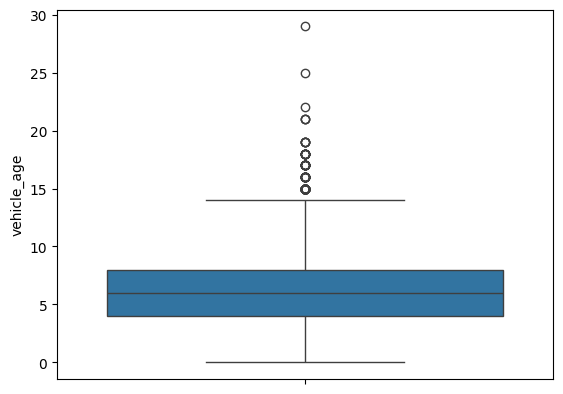

In [ ]:
sns.boxplot(df['vehicle_age'])

<Axes: ylabel='km_driven'>

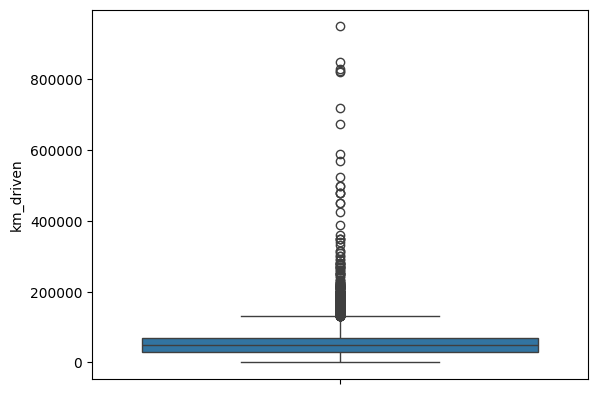

In [ ]:
sns.boxplot(df['km_driven'])

<Axes: ylabel='mileage'>

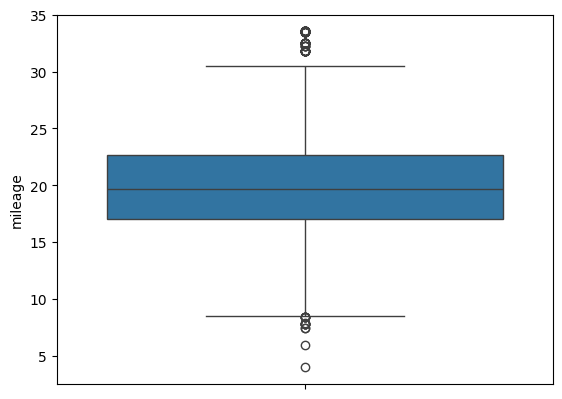

In [ ]:
sns.boxplot(df['mileage'])

<Axes: ylabel='engine'>

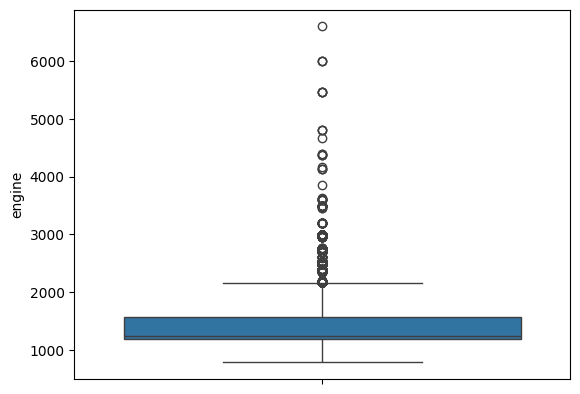

In [ ]:
sns.boxplot(df['engine'])

#**Train-Test Split**

In [ ]:
X = df.drop(columns=['selling_price'])
y = df['selling_price']

In [ ]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42)

# **The Distribution of Data**

In [ ]:
df[['km_driven', 'mileage','engine']].skew()

,0
km_driven,5.019741
mileage,0.104985
engine,1.667107


/tmp/ipykernel_3640/635629501.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_series)


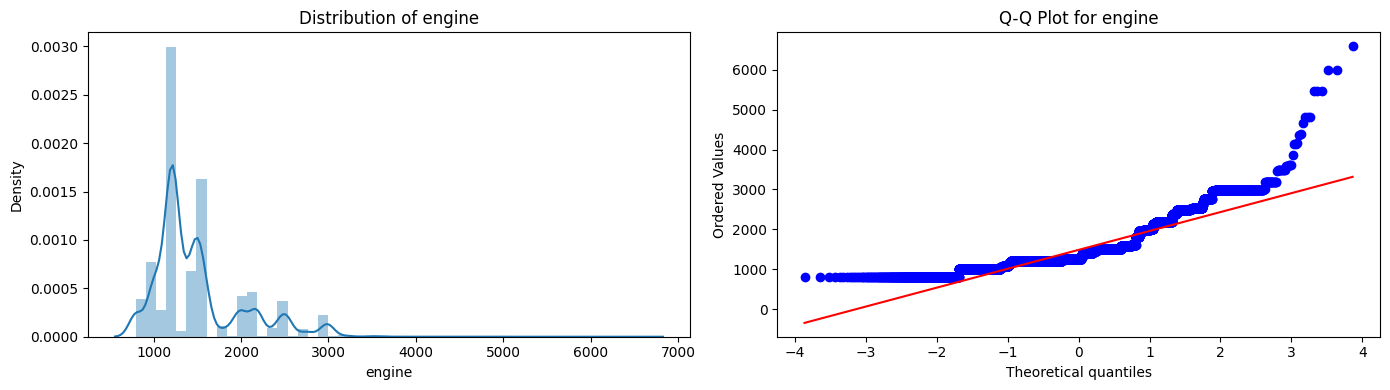

/tmp/ipykernel_3640/635629501.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_series)


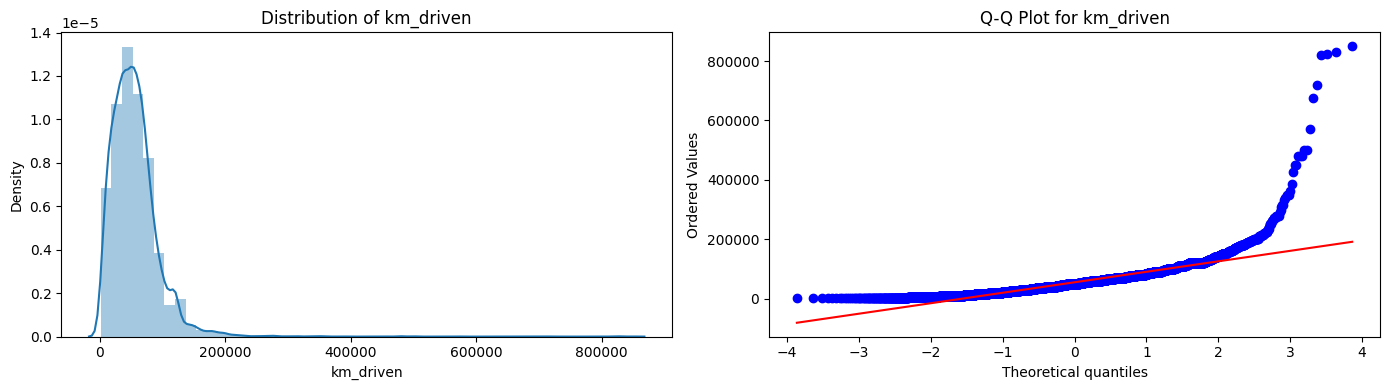

/tmp/ipykernel_3640/635629501.py:13: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(data_series)


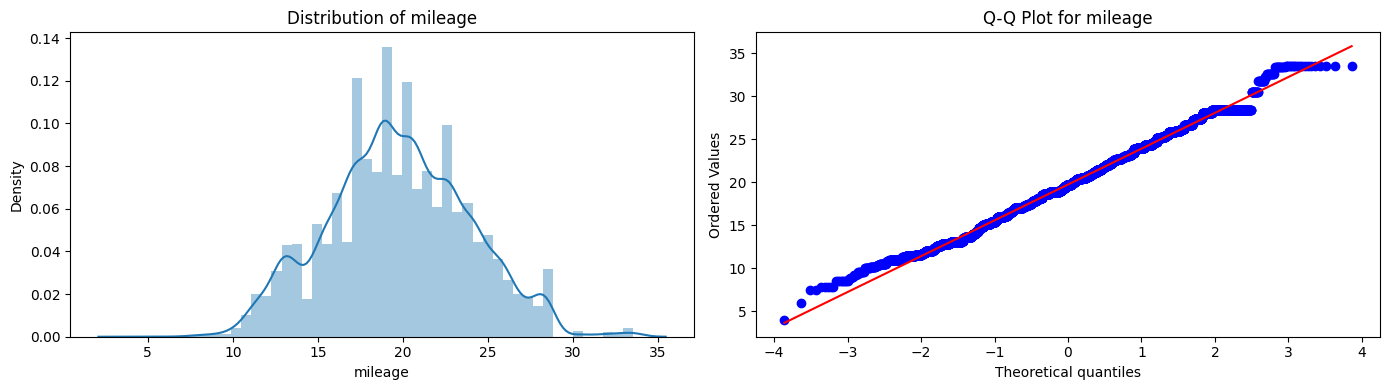

In [ ]:
import scipy.stats as stats

plot_data_sources = {
    'engine': X_train['engine'],
    'km_driven': X_train['km_driven'],
    'mileage': X_train['mileage']
}

for col_name, data_series in plot_data_sources.items():
    plt.figure(figsize=(14,4))

    plt.subplot(121)
    sns.distplot(data_series)
    plt.title(f'Distribution of {col_name}')

    plt.subplot(122)
    stats.probplot(data_series, dist="norm", plot=plt)
    plt.title(f'Q-Q Plot for {col_name}')

    plt.tight_layout()
    plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import OneHotEncoder,FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

#**Preprocessing**

In [ ]:
preprocessor = ColumnTransformer(transformers=[('log', FunctionTransformer(np.log1p), ['km_driven','engine']),
                          ('ohe',OneHotEncoder(drop='first',handle_unknown='ignore'),['brand','seller_type','fuel_type','transmission_type'])
                          ],remainder='passthrough')


#**Pipeline**

In [ ]:
pipe = Pipeline(steps=[('preprocessor',preprocessor),('regressor',LinearRegression())])

In [ ]:
pipe.fit(X_train, y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('log',
                                                  FunctionTransformer(func=<ufunc 'log1p'>),
                                                  ['km_driven', 'engine']),
                                                 ('ohe',
                                                  OneHotEncoder(drop='first',
                                                                handle_unknown='ignore'),
                                                  ['brand', 'seller_type',
                                                   'fuel_type',
                                                   'transmission_type'])])),
                ('regressor', LinearRegression())])

In [ ]:
y_pred = pipe.predict(X_test)

In [ ]:
r2_score(y_test,y_pred)

0.7232505029887839

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE:", mae)
print("MSE:", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE: 230278.33432225505
MSE: 200457822939.1668
RMSE: 447725.1645140876
R² Score: 0.7232505029887839


#**Saving the Trained Model**

In [ ]:
import pickle

In [ ]:
pickle.dump(pipe,open('model.pkl','wb'))